# Transformer Anatomy: Building the Block Step-by-Step

In this workshop, we move away from RNNs and build a **Transformer Block** from scratch. 

We will focus on the conceptual "anatomy" of why each component exists.

In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

In [2]:
# Dataset: Sentiment analysis
data = [
    ("I love this english movie", 1),
    ("This english film was amazing", 1),
    ("I hated this movie in english language", 0),
    ("Worst film ever seen in english", 0)
]

vocab = {"<PAD>": 0}
for s, _ in data:
    for w in s.lower().split():
        if w not in vocab: vocab[w] = len(vocab)

def prepare(s, v):
    idx = [v[w] for w in s.lower().split()]
    return torch.tensor(idx, dtype=torch.long).unsqueeze(0)

vocab_sz = len(vocab)
print(f"Vocab Size: {vocab_sz}")

Vocab Size: 15


In [3]:
vocab

{'<PAD>': 0,
 'i': 1,
 'love': 2,
 'this': 3,
 'english': 4,
 'movie': 5,
 'film': 6,
 'was': 7,
 'amazing': 8,
 'hated': 9,
 'in': 10,
 'language': 11,
 'worst': 12,
 'ever': 13,
 'seen': 14}

## Step 1: Positional Encoding (The Sense of Order)

### Concept
Unlike RNNs, Transformers process all words at once (in parallel). Without Positional Encoding, the model sees the sentence as a **bag of words** (it wouldn't know the difference between 'Dog bites Man' and 'Man bites Dog').

We add a unique vector to each word based on its position in the sentence.

In [4]:
class PosEmb(nn.Module):
    def __init__(self, max_len, e_dim):
        super().__init__()
        # Learned positional embeddings for simplicity
        self.p_emb = nn.Embedding(max_len, e_dim)
        
    def forward(self, x):
        pos = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        return self.p_emb(pos)

# Example: Inspecting Positional Vectors
# Let's see what the model adds to the first 3 words
p_model = PosEmb(10, 4)
dummy_x = torch.zeros(1, 3)
v_pos = p_model(dummy_x)
print("Positional Vectors (first 3 words):\n", v_pos.squeeze(0).detach().numpy())

Positional Vectors (first 3 words):
 [[ 1.4374028   1.0707974  -0.87722695  0.55053943]
 [-0.00779008 -0.12390747 -2.187985   -0.26070935]
 [-0.18249343  0.20786804  0.00354122  0.18035646]]


## Step 2: Scaled Dot-Product Attention (The Similarity Logic)

### Concept
Attention calculates how "similar" two words are using their dot product. 
1. **Query (Q)**: What I am looking for.
2. **Key (K)**: What I have.
3. **Value (V)**: The information I am sharing.

We scale the scores by $\sqrt{d_k}$ to prevent gradients from exploding.

In [5]:
def attention(q, k, v):
    # Similarity using Dot Product
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    w = F.softmax(scores, dim=-1)
    return torch.matmul(w, v), w

# Example: Forming the Attention Score
q_ex = torch.tensor([[1.0, 0.0, 0.0]]) # Looking for type A
k_ex = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]]) # Word 0 is type A, Word 1 is type B

sim = torch.matmul(q_ex, k_ex.T) / math.sqrt(3)
w_ex = F.softmax(sim, dim=-1)
print("Similarity Weights (Numerical Example):", w_ex[0].tolist())

Similarity Weights (Numerical Example): [0.6404574513435364, 0.35954248905181885]


## Step 3: Multi-Head Logic (Parallel Perspectives)

### Concept
Instead of one big attention head, we split the embedding into multiple small heads. This allows the model to focus on **different relationships** at once (e.g., one head for grammar, one for sentiment).

In [6]:
class MHA(nn.Module):
    def __init__(self, embed_dim, heads):
        super().__init__()
        self.heads = heads
        self.dim_head = embed_dim // heads # dimension of each head
        
        self.q_lin = nn.Linear(embed_dim, embed_dim)
        self.k_lin = nn.Linear(embed_dim, embed_dim)
        self.v_lin = nn.Linear(embed_dim, embed_dim)
        self.o_lin = nn.Linear(embed_dim, embed_dim)
        
    def forward(self, x):
        batch, length, embed_dim = x.size() # batch, length, embed_dim
        # Linear transforms and splitting into heads
        q = self.q_lin(x).view(batch, length, self.heads, self.dim_head).transpose(1, 2)
        k = self.k_lin(x).view(batch, length, self.heads, self.dim_head).transpose(1, 2)
        v = self.v_lin(x).view(batch, length, self.heads, self.dim_head).transpose(1, 2)
        
        out, weights = attention(q, k, v)
        # Re-combine heads
        out = out.transpose(1, 2).contiguous().view(batch, length, embed_dim)
        return self.o_lin(out), weights

## Step 4: Add & Norm (The Training Stability)

### Concept
Deep networks are hard to train because gradients can vanish. We use:
1. **Residual (Add)**: Adding the input back to the output of a layer (`x + SubLayer(x)`).
2. **LayerNorm**: Keeping the values in a stable range so training doesn't blow up.

In [7]:
class TransBlock(nn.Module):
    def __init__(self, e_dim, heads, f_dim):
        super().__init__()
        self.attn = MHA(e_dim, heads)
        self.norm1 = nn.LayerNorm(e_dim)
        self.norm2 = nn.LayerNorm(e_dim)
        
        self.ff = nn.Sequential(
            nn.Linear(e_dim, f_dim),
            nn.ReLU(),
            nn.Linear(f_dim, e_dim)
        )
        
    def forward(self, x):
        # Sublayer 1: Attention + Add & Norm
        attn_out, w = self.attn(x)
        x = self.norm1(x + attn_out)
        # Sublayer 2: Feed Forward + Add & Norm
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x, w

## Step 5: The Full Transformer Classifier

In [8]:
class TransModel(nn.Module):
    def __init__(self, v_sz, e_dim, heads, f_dim, out_sz, max_len=10):
        super().__init__()
        self.w_emb = nn.Embedding(v_sz, e_dim)
        self.p_emb = PosEmb(max_len, e_dim)
        self.block = TransBlock(e_dim, heads, f_dim)
        self.fc = nn.Linear(e_dim, out_sz)
        
    def forward(self, x):
        x = self.w_emb(x) + self.p_emb(x)
        x, w = self.block(x)
        # Average pooling over the sequence
        x = x.mean(dim=1)
        return self.fc(x), w

## Step 6: Training & Head Visualization

Epoch 10, Loss: 0.0315
Epoch 20, Loss: 0.0072
Epoch 30, Loss: 0.0041
Epoch 40, Loss: 0.0027
Epoch 50, Loss: 0.0019


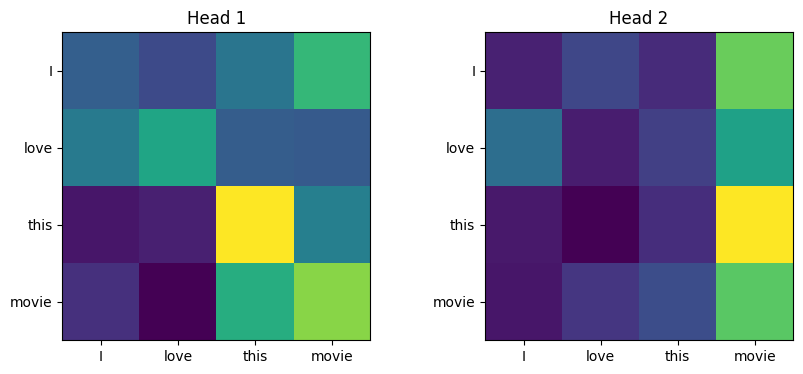

In [9]:
model = TransModel(vocab_sz, 16, 2, 32, 2) # vocab_sz, e_dim, n_heads, f_dim, n_layers
optimizer = opt.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(50):
    total_loss = 0
    for s, l in data:
        optimizer.zero_grad()
        x, target = prepare(s, vocab), torch.tensor([l])
        out, _ = model(x)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss +=   loss.item()
    if (epoch+1) % 10 == 0: print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Visualize 2 Heads for a sentence
x_input = prepare("I love this movie", vocab)
_, weights = model(x_input)

heads = weights[0].detach().numpy() # (heads, seq, seq)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
words = "I love this movie".split()

num_of_heads = 2
for i in range(num_of_heads):
    ax[i].imshow(heads[i])
    ax[i].set_title(f"Head {i+1}")
    ax[i].set_xticks(range(len(words)), words)
    ax[i].set_yticks(range(len(words)), words)
plt.show()

# Transformer Anatomy Workshop

To deepen your understanding of Transformers, consider the following:
1. **Attention Visualization**: Use heatmaps to visualize the attention weights between tokens to see what the model "focuses" on.
2. **Implement GPT/BERT**: Adapt this architecture into a decoder-only (GPT) or encoder-only (BERT) configuration to understand their specific use cases.
3. **Weight Initialization**: Experiment with different initialization strategies (like Xavier or K) and observe their impact on training stability.
4. **Hugging Face Integration**: Compare your scratch implementation with the optimized versions in the `transformers` library.
